In [2]:
%load_ext autoreload
%autoreload 2
import sys
import os
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src import file_io as fio

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import itertools
from scipy.constants import year
from scipy.stats import gaussian_kde

In [4]:
import mpl_scatter_density # adds projection='scatter_density'
from matplotlib.colors import LinearSegmentedColormap
# Make the norm object to define the image stretch
from astropy.visualization import LogStretch
from astropy.visualization.mpl_normalize import ImageNormalize
norm = ImageNormalize(vmin=0., vmax=1000, stretch=LogStretch())

In [5]:
# chandra low high table
raw_chandra = [
    ["pha_a", 3.00, 30.00],
    ["pha_b", 3.00, 45.00],
    ["pha_c", 16.07, 166.70],
    ["pha_d", 20.00, 225.00],
    ["pha_e", 20.00, 225.00]
]
factor_chandra = pd.DataFrame(data=raw_chandra, columns=["detector", 0, 1])
factor_chandra.set_index("detector", inplace=True)

# magic number in chandra paper pha = tlm/1023 * factor
magic_chandra = 1023

In [6]:
#quick test
factor_chandra.loc["pha_c", 0]

np.float64(16.07)

In [7]:
def calc_de_dx(row):
    return row["pha_a"] / magic_chandra * factor_chandra.loc["pha_a", row["a_lh_flag"]]

def calc_total_energy(row, to_d=True, to_e=True):
    apply_factors =  row["pha_a"] * factor_chandra.loc["pha_a", row["a_lh_flag"]] + \
                     row["pha_b"] * factor_chandra.loc["pha_b", row["b_lh_flag"]] + \
                     row["pha_c"] * factor_chandra.loc["pha_c", row["c_lh_flag"]]
    to_e = to_e and to_d
    if to_e or to_d:
        apply_factors += row["pha_d"] * factor_chandra.loc["pha_d", row["d_lh_flag"]]
    if to_e:
        apply_factors += row["pha_e"] * factor_chandra.loc["pha_e", row["e_lh_flag"]]
        
    return apply_factors / magic_chandra

In [8]:
path = fio.get_data_files("phx", "1996", "67")[0]
df = fio.read_pha(path)

df = df[(df["a_seg"] == 0) & (df["a_seg"] == df["b_seg"])]
df["de/dx"] = df.apply(calc_de_dx, axis=1)
df["total_energy"] = df.apply(calc_total_energy, axis=1)

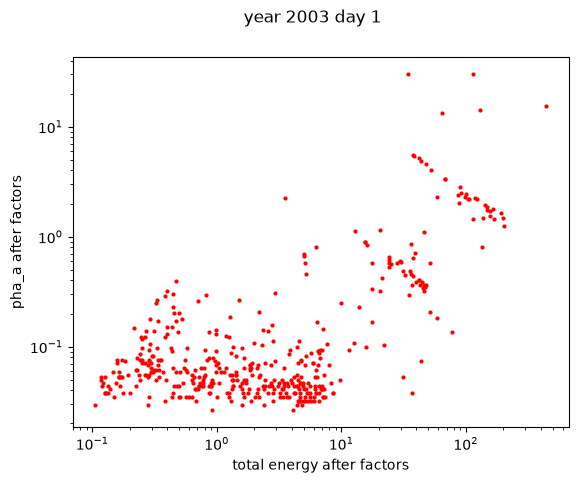

<Figure size 640x480 with 0 Axes>

In [9]:
fig, ax = plt.subplots()
ax.set_xlabel("total energy after factors")
ax.set_xscale('log')
ax.set_ylabel("pha_a after factors")
ax.set_yscale('log')
ax.scatter(df["total_energy"], df["de/dx"], s=4, c='r')
fig.suptitle("year 2003 day 1")
plt.show()
plt.clf()

In [10]:
# now do it again for 1996

files_1996 = fio.get_data_files("phx", "1996")
accum = pd.concat([fio.read_pha(f) for f in files_1996])

In [11]:
filtered = accum[(accum["a_seg"] == 0) & (accum["b_seg"] == 0)]
filtered["de/dx"] = filtered.apply(calc_de_dx, axis=1)
filtered["total_energy"] = filtered.apply(calc_total_energy, axis=1)

In [12]:
# remove 0 readings
diff_nonzero = filtered["de/dx"] != 0
total_nonzero = filtered["total_energy"] != 0
filtered = filtered[diff_nonzero & total_nonzero]

# filtered = filtered[(filtered["total_energy"] != 0) & (filtered["de/dx" != 0])]
# filtered["log_energy"] = np.log10(filtered["total_energy"])
# filtered["log_de_dx"] = np.log10(filtered["de/dx"])
# filtered["log_sum"] = filtered["log_energy"] + filtered["log_de_dx"]

In [13]:
#maybe_protons = filtered.loc[filtered["log_sum"].between(0.5, 1.5)]
#maybe_he = filtered.loc[filtered["log_sum"].between(1.5, 2.6)]
#probably_electrons = filtered.loc[filtered["log_sum"].le(0.5)]

/home/chuang/miniconda3/envs/ephin/lib/python3.14/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/chuang/miniconda3/envs/ephin/lib/python3.14/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


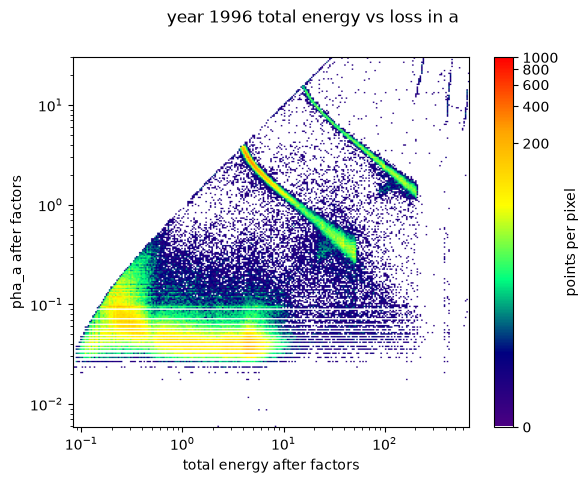

<function matplotlib.pyplot.clf() -> 'None'>

In [14]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.set_xlabel("total energy after factors")
ax.set_xscale("log")
ax.set_ylabel("pha_a after factors")
ax.set_yscale("log")

'''
# plot protons?
stack = np.vstack([maybe_protons["total_energy"], maybe_protons["de/dx"]])
density = gaussian_kde(stack)(stack)
ax.scatter(maybe_protons["total_energy"], maybe_protons["de/dx"], s=1, c=density, label="maybe protons")

# plot he?
stack = np.vstack([maybe_he["total_energy"], maybe_he["de/dx"]])
density = gaussian_kde(stack)(stack)
ax.scatter(maybe_he["total_energy"], maybe_he["de/dx"], s=1, c=density, label="maybe protons")

# plot the electrons
stack = np.vstack([probably_electrons["total_energy"], probably_electrons["de/dx"]])
density = gaussian_kde(stack)(stack)
ax.scatter(probably_electrons["total_energy"], probably_electrons["de/dx"], s=1, c=density, label="probably electrons")
'''
# hacky color map
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', [
    (0, 'white'),
    (1e-20, 'indigo'),
    (0.2, 'navy'),
    (0.4, 'springgreen'),
    (0.6, 'yellow'),
    (0.8, 'orange'),
    (1, 'red'),
], N=256)

# try a log normed density map
density = ax.scatter_density(filtered['total_energy'], filtered['de/dx'], norm=norm, cmap=custom_cmap)
fig.colorbar(density, label='points per pixel')

fig.suptitle("year 1996 total energy vs loss in a")
plt.show()
plt.clf

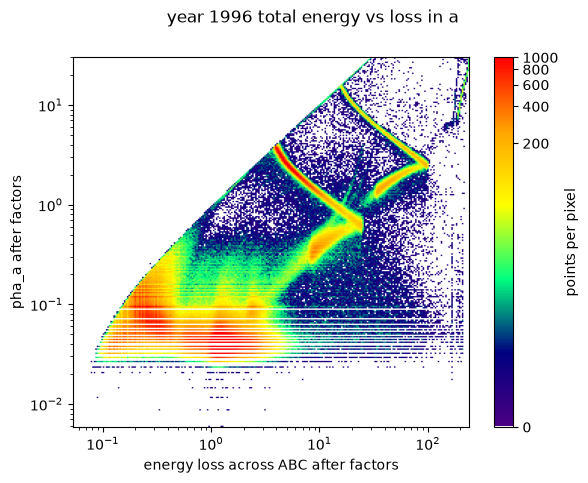

<function matplotlib.pyplot.clf() -> 'None'>

In [15]:
# let's try again with only ABC
filtered = accum[accum["a_seg"] == accum["b_seg"]]
filtered["de/dx"] = filtered.apply(calc_de_dx, axis=1)
filtered['energy loss across ABC'] = filtered.apply(calc_total_energy, axis=1, to_d=False)
# remove 0 readings
diff_nonzero = filtered["de/dx"] != 0
total_nonzero = filtered['energy loss across ABC'] != 0
filtered = filtered[diff_nonzero & total_nonzero]
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.set_xlabel("energy loss across ABC after factors")
ax.set_xscale("log")
ax.set_ylabel("pha_a after factors")
ax.set_yscale("log")
# hacky color map
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', [
    (0, 'white'),
    (1e-20, 'indigo'),
    (0.2, 'navy'),
    (0.4, 'springgreen'),
    (0.6, 'yellow'),
    (0.8, 'orange'),
    (1, 'red'),
], N=256)

# try a log normed density map
density = ax.scatter_density(filtered['energy loss across ABC'], filtered['de/dx'], norm=norm, cmap=custom_cmap)
fig.colorbar(density, label='points per pixel')

fig.suptitle("year 1996 total energy vs loss in a")
plt.show()
plt.clf

In [16]:
# what a weird artifact. does this happen for other years???
# let's try this for 1997-2001

finished 1997
finished 1998


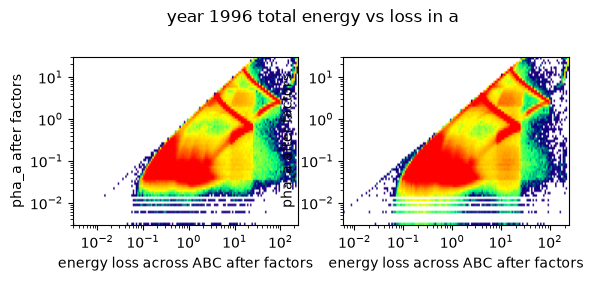

<function matplotlib.pyplot.clf() -> 'None'>

In [17]:
fig = plt.figure()
for year_num in range(1997, 1999): # range is start inclusive end exclusive
    year_str = str(year_num)

    files_year = fio.get_data_files("phx",  year_str)
    accum = []
    for f in files_year:
        try:
            temp = fio.read_pha(f)
            # the files are surprisingly messy, here's some clean up
            temp = temp[pd.to_numeric(temp['pha_a'], errors='coerce').notnull()]
            temp = temp[pd.to_numeric(temp['pha_b'], errors='coerce').notnull()]
            temp = temp[pd.to_numeric(temp['pha_c'], errors='coerce').notnull()]
            
            accum.append(temp)
        except pd.errors.EmptyDataError:
            continue
    accum = pd.concat(accum) # kind of wasteful but better than reallocating constantly
    
    same_seg = accum["a_seg"] == accum["b_seg"]
    filtered = accum[same_seg]
    filtered["de/dx"] = filtered.apply(calc_de_dx, axis=1)
    filtered['energy loss across ABC'] = filtered.apply(calc_total_energy, axis=1, to_d=False)
    # remove 0 readings
    diff_nonzero = filtered["de/dx"] != 0
    total_nonzero = filtered['energy loss across ABC'] != 0
    filtered = filtered[diff_nonzero & total_nonzero]

    index = year_num - 1996
    ax = fig.add_subplot(2, 2, index, projection='scatter_density')
    ax.set_xlabel("energy loss across ABC after factors")
    ax.set_xscale("log")
    ax.set_ylabel("pha_a after factors")
    ax.set_yscale("log")


    # try a log normed density map
    density = ax.scatter_density(filtered['energy loss across ABC'], filtered['de/dx'], norm=norm, cmap=custom_cmap)
    print(f'finished {year_str}')

fig.suptitle("year 1997-1998 total energy vs loss in a")
plt.show()
plt.clf

In [18]:
# so this is some kind of real pattern

SyntaxError: invalid syntax (1117105441.py, line 1)

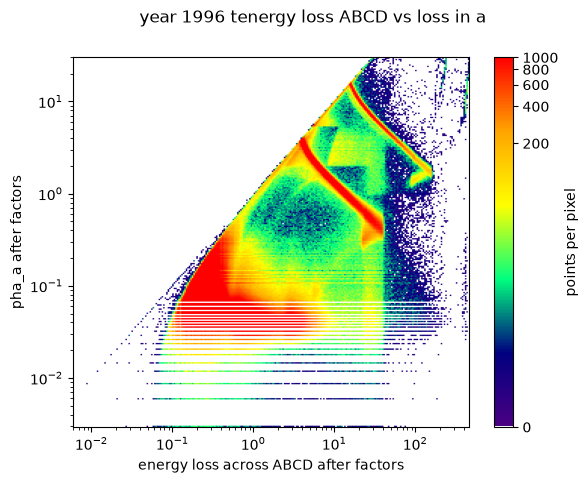

<function matplotlib.pyplot.clf() -> 'None'>

In [19]:
# let's try again with only ABC
filtered = accum[accum["a_seg"] == accum["b_seg"]]
filtered["de/dx"] = filtered.apply(calc_de_dx, axis=1)
filtered['energy loss across ABCD'] = filtered.apply(calc_total_energy, axis=1, to_e=False)
# remove 0 readings
diff_nonzero = filtered["de/dx"] != 0
total_nonzero = filtered['energy loss across ABCD'] != 0
filtered = filtered[diff_nonzero & total_nonzero]
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.set_xlabel("energy loss across ABCD after factors")
ax.set_xscale("log")
ax.set_ylabel("pha_a after factors")
ax.set_yscale("log")
# hacky color map
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', [
    (0, 'white'),
    (1e-20, 'indigo'),
    (0.2, 'navy'),
    (0.4, 'springgreen'),
    (0.6, 'yellow'),
    (0.8, 'orange'),
    (1, 'red'),
], N=256)

# try a log normed density map
density = ax.scatter_density(filtered['energy loss across ABCD'], filtered['de/dx'], norm=norm, cmap=custom_cmap)
fig.colorbar(density, label='points per pixel')

fig.suptitle("year 1996 tenergy loss ABCD vs loss in a")
plt.show()
plt.clf